In [ ]:
! pip install torch torch-geometric pandas numpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 28.8 MB/s eta 0:00:00


In [ ]:
!pip install ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 36.9 MB/s eta 0:00:00


https://pytorch-geometric.readthedocs.io/en/latest/modules/nn.html#torch_geometric.nn.conv.GraphConv

https://youtu.be/JWswItMRvg4?si=MLDJpIWqokEiwWU1

In [ ]:
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv

In [ ]:
import pandas as pd
import numpy as np
import torch
from torch import nn
import torch.nn.functional as F
from tqdm import tqdm
from tqdm.notebook import tqdm # Use this if you are in a Notebook/Colab

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving final_sorted.csv to final_sorted.csv


In [ ]:
df_reddit = pd.read_csv('final_sorted.csv')
df_reddit

,from,to,time,utc,post.id,comment.id,parent.id
0,Professional_Feed478,Professional_Feed478,2020-12-01 02:05:52,1606784752,k4a18g,k4a18g,k4a18g
1,Sporklin,Professional_Feed478,2020-12-01 02:24:55,1606785895,k4a18g,ge7onzo,t3_k4a18g
2,shibe5,Professional_Feed478,2020-12-01 02:44:12,1606787052,k4a18g,ge7qspw,t3_k4a18g
3,HubertHamster,HubertHamster,2020-12-01 03:19:57,1606789197,k4bdlt,k4bdlt,k4bdlt
4,AutoModerator,HubertHamster,2020-12-01 03:19:58,1606789198,k4bdlt,ge7usya,t3_k4bdlt
...,...,...,...,...,...,...,...
3330330,LEGACYlock,LAG4739,2021-07-31 23:57:23,1627768643,ovd5e0,h78x9gw,t3_ovd5e0
3330331,Nawmannah,spicytomatopasteanon,2021-07-31 23:57:32,1627768652,ov5r7s,h78xa3j,t1_h78wzcy
3330332,Ravengm,DistinctEngineering2,2021-07-31 23:58:09,1627768689,ov9uyj,h78xcmh,t1_h77t94e
3330333,Otherwise_Baby_6930,AFRO-1015,2021-07-31 23:58:44,1627768724,ov5r7s,h78xf3p,t1_h78w9fg


In [ ]:
# -----------------------------
# 0) Prepare time bins + edges
# -----------------------------
df = df_reddit.copy()
df['datetime_utc'] = pd.to_datetime(df['utc'], unit='s', utc=True)
df['hour'] = df['datetime_utc'].dt.floor('h')
#df_reddit["datetime_utc"] = pd.to_datetime(df_reddit["utc"], unit="s", utc=True)
df["day"] = df['datetime_utc'].dt.floor('D')
df["week"] =df['datetime_utc'].dt.to_period('W-MON').dt.start_time
df = df.drop(columns=['time', 'utc'])
df

/tmp/ipykernel_488/724008783.py:9: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df["week"] =df['datetime_utc'].dt.to_period('W-MON').dt.start_time


,from,to,post.id,comment.id,parent.id,datetime_utc,hour,day,week
0,Professional_Feed478,Professional_Feed478,k4a18g,k4a18g,k4a18g,2020-12-01 01:05:52+00:00,2020-12-01 01:00:00+00:00,2020-12-01 00:00:00+00:00,2020-12-01
1,Sporklin,Professional_Feed478,k4a18g,ge7onzo,t3_k4a18g,2020-12-01 01:24:55+00:00,2020-12-01 01:00:00+00:00,2020-12-01 00:00:00+00:00,2020-12-01
2,shibe5,Professional_Feed478,k4a18g,ge7qspw,t3_k4a18g,2020-12-01 01:44:12+00:00,2020-12-01 01:00:00+00:00,2020-12-01 00:00:00+00:00,2020-12-01
3,HubertHamster,HubertHamster,k4bdlt,k4bdlt,k4bdlt,2020-12-01 02:19:57+00:00,2020-12-01 02:00:00+00:00,2020-12-01 00:00:00+00:00,2020-12-01
4,AutoModerator,HubertHamster,k4bdlt,ge7usya,t3_k4bdlt,2020-12-01 02:19:58+00:00,2020-12-01 02:00:00+00:00,2020-12-01 00:00:00+00:00,2020-12-01
...,...,...,...,...,...,...,...,...,...
3330330,LEGACYlock,LAG4739,ovd5e0,h78x9gw,t3_ovd5e0,2021-07-31 21:57:23+00:00,2021-07-31 21:00:00+00:00,2021-07-31 00:00:00+00:00,2021-07-27
3330331,Nawmannah,spicytomatopasteanon,ov5r7s,h78xa3j,t1_h78wzcy,2021-07-31 21:57:32+00:00,2021-07-31 21:00:00+00:00,2021-07-31 00:00:00+00:00,2021-07-27
3330332,Ravengm,DistinctEngineering2,ov9uyj,h78xcmh,t1_h77t94e,2021-07-31 21:58:09+00:00,2021-07-31 21:00:00+00:00,2021-07-31 00:00:00+00:00,2021-07-27
3330333,Otherwise_Baby_6930,AFRO-1015,ov5r7s,h78xf3p,t1_h78w9fg,2021-07-31 21:58:44+00:00,2021-07-31 21:00:00+00:00,2021-07-31 00:00:00+00:00,2021-07-27


In [ ]:
edges = df[["week", "from", "to"]].copy()
edges = edges[edges["from"] != edges["to"]]  # dont count self loops as it is not really good for influence
edges

,week,from,to
1,2020-12-01,Sporklin,Professional_Feed478
2,2020-12-01,shibe5,Professional_Feed478
4,2020-12-01,AutoModerator,HubertHamster
7,2020-12-01,shibe5,tomcarbon
8,2020-12-01,MadSmatter,tomcarbon
...,...,...,...
3330329,2021-07-27,Nawmannah,Yololife5718
3330330,2021-07-27,LEGACYlock,LAG4739
3330331,2021-07-27,Nawmannah,spicytomatopasteanon
3330332,2021-07-27,Ravengm,DistinctEngineering2


In [ ]:
weeks = sorted(edges["week"].unique())
users = pd.Index(pd.unique(pd.concat([edges["from"], edges["to"]], axis=0)))
user2id = {u: i for i, u in enumerate(users)}
N = len(users)
print("Num users:", N)

Num users: 389931


In [ ]:
user2id

{'Sporklin': 0,
 'shibe5': 1,
 'AutoModerator': 2,
 'MadSmatter': 3,
 'drdoge_': 4,
 'SisypheanExistance': 5,
 'RealDreamTanks': 6,
 '_nformant': 7,
 'ectocody84': 8,
 'JJ1013Reddit': 9,
 'tomcarbon': 10,
 'sodogetip': 11,
 'MadeUAcctButIEatedIt': 12,
 'RunningDogeTheGame': 13,
 'the_soviet_union_69': 14,
 'Pdvsky': 15,
 'SaintAssassinDirk': 16,
 'NinjaTank707': 17,
 'dash4385': 18,
 'MmmmmmmZadi69': 19,
 'Cwright333': 20,
 'BumJamber': 21,
 'Morphior': 22,
 'voterosticon': 23,
 'Few_Click_4065': 24,
 'Local_Judge': 25,
 'kwasnydiesel': 26,
 'An_Unusual_Mind': 27,
 'Ol_FloppySeal': 28,
 'Mortgage-Pitiful': 29,
 'Elias1912': 30,
 'Red5point1': 31,
 'Leetybeef': 32,
 'AndyIsh': 33,
 'Makemoneyfromhome85': 34,
 'ThatKentuckyDude': 35,
 'L103131': 36,
 'Stealthex_io': 37,
 'Lancer37': 38,
 'bbooth92': 39,
 'DogeApachey': 40,
 'v4x2017': 41,
 'GreenRangerKeto': 42,
 'dagostiino': 43,
 'GoodShibe': 44,
 'Raw-Doggin183': 45,
 'relyt822': 46,
 'kst8er': 47,
 'Elegant_777222': 48,
 'zeeblefritz

In [ ]:
print(list(user2id.keys())[list(user2id.values()).index(361512)])

Trekens


In [ ]:
def build_graph_for_week(h):
    """
    Constructs a PyTorch Geometric (PyG) Data object for a specific week 'h'.
    This converts raw interaction rows into a network structure the AI can read.

    Input: Time  period

    Return: PyG Data object, with edge_index (map) and count in degrees and out degrees.
    """
    # 1. Slice the dataframe to only include interactions from this specific week
    e = edges[edges["week"] == h]

    # If no activity happened this week, return None to avoid training on empty data
    if len(e) == 0:
        return None

    # 2. Convert Usernames to Integer IDs (Mapping)
    # src: The 'Senders' (Users who started the interaction/replied)
    src = e["from"].map(user2id).to_numpy()
    # dst: The 'Receivers' (Users who were replied to/received attention)
    dst = e["to"].map(user2id).to_numpy()

    # 3. Create the 'Map' (Topology)
    # This stacks the senders on top of the receivers to create a [2, num_edges] tensor.
    # It tells the GNN exactly who is connected to whom.
    edge_index = torch.tensor(np.vstack([src, dst]), dtype=torch.long)

    # 4. Feature Engineering: Node Degrees
    # out_deg: Count of messages SENT per user. High out_deg = Very active/talkative user.
    out_deg = np.bincount(src, minlength=N)
    # in_deg: Count of messages RECEIVED per user. High in_deg = Popular/Influential user.
    in_deg = np.bincount(dst, minlength=N)

    # 5. Create the Feature Matrix (x)
    # We stack out-degree and in-degree side-by-side.
    # Result: A matrix where row 'i' is [sent_count, received_count] for user 'i'.
    # This represents the 'status' or 'profile' of the node before looking at the graph structure.
    x = torch.tensor(np.vstack([out_deg, in_deg]).T, dtype=torch.float)

    # 6. Package into a PyG Data Object
    # Interpretation: This is a single 'snapshot' of the network.
    # 'x' is what the nodes look like, 'edge_index' is how they are linked.
    return Data(x=x, edge_index=edge_index)

def next_hour_labels(h_next, tau_quantile=0.90):
    """
    Creates binary 'answer key' (labels) for the next time step.
    1 = Influencer (Top 10%), 0 = Regular User.
    """

    # 1. Filter raw data to look ONLY at the next week/hour
    e = edges[edges["week"] == h_next]

    # 2. Extract the 'destination' (the users being replied to)
    # Mapping usernames to IDs to keep indices consistent with the feature matrix (x)
    dst = e["to"].map(user2id).to_numpy()

    # 3. Count how many times each user ID appears as a destination
    # This creates an array of size N where in_deg[i] is the number of replies user i received
    in_deg = np.bincount(dst, minlength=N)

    # 4. Calculate the 'Elite' threshold (The 90th percentile)
    # We only look at active users (in_deg > 0) to find the threshold.
    # If no one is active, we default the threshold to 1.0.
    thr = np.quantile(in_deg[in_deg > 0], tau_quantile) if (in_deg > 0).any() else 1.0

    # 5. Create the BINARY label (The Core Logic)
    # Comparison results in True/False, .astype(np.int64) converts to:
    # 1: Influencer (if their in-degree is in the top 10% of the active users)
    # 0: Regular/Silent User (if they fall anywhere below that top 10% mark)
    y = (in_deg >= thr).astype(np.int64)

    # 6. Convert to PyTorch tensor so the model can use it for Loss calculation
    return torch.tensor(y, dtype=torch.long)

In [ ]:
# -----------------------------
# 2) Build dataset of (G_t -> y_{t+1})
# -----------------------------

# We loop through each week, build the graph for that week, and then create the labels for the next week.
WEEKS = []
for i in range(len(weeks) - 1):
    h = weeks[i] # Current week (Graph snapshot)
    h_next = weeks[i + 1] # Next week (what we want to predict)
    G = build_graph_for_week(h) # Build the graph for the current week returns a PyG Data object
    if G is None:
        continue
    y = next_hour_labels(h_next, tau_quantile=0.90) # Create the labels for the next week (1 if influencer, 0 if not)
    G.y = y # Attach the labels to the graph data object. Now G contains both the structure (x, edge_index) and the target (y).
    WEEKS.append(G)

print("Num graph snapshots:", len(WEEKS))

Num graph snapshots: 34


In [ ]:
WEEKS

[Data(x=[389931, 2], edge_index=[2, 403], y=[389931]),
 Data(x=[389931, 2], edge_index=[2, 474], y=[389931]),
 Data(x=[389931, 2], edge_index=[2, 916], y=[389931]),
 Data(x=[389931, 2], edge_index=[2, 1094], y=[389931]),
 Data(x=[389931, 2], edge_index=[2, 6539], y=[389931]),
 Data(x=[389931, 2], edge_index=[2, 6223], y=[389931]),
 Data(x=[389931, 2], edge_index=[2, 3343], y=[389931]),
 Data(x=[389931, 2], edge_index=[2, 2165], y=[389931]),
 Data(x=[389931, 2], edge_index=[2, 230688], y=[389931]),
 Data(x=[389931, 2], edge_index=[2, 236675], y=[389931]),
 Data(x=[389931, 2], edge_index=[2, 164544], y=[389931]),
 Data(x=[389931, 2], edge_index=[2, 84779], y=[389931]),
 Data(x=[389931, 2], edge_index=[2, 46520], y=[389931]),
 Data(x=[389931, 2], edge_index=[2, 40213], y=[389931]),
 Data(x=[389931, 2], edge_index=[2, 37998], y=[389931]),
 Data(x=[389931, 2], edge_index=[2, 31977], y=[389931]),
 Data(x=[389931, 2], edge_index=[2, 21255], y=[389931]),
 Data(x=[389931, 2], edge_index=[2, 219

## Lets look at the interpretation of this:

In [ ]:
WEEKS[0].x.transpose(0, 1)

tensor([[18., 24., 26.,  ...,  0.,  0.,  0.],
        [13., 17.,  1.,  ...,  0.,  0.,  0.]])

In [ ]:
print(WEEKS[0].x[:, 0]) # this counts the time user i has replied on week 1

# We can check this because its lenght should be equal to N

len(WEEKS[0].x[:, 0]) # and indeed it is

tensor([18., 24., 26.,  ...,  0.,  0.,  0.])


389931

In [ ]:
WEEKS[0].edge_index[0] # sender list (source nodes) for every single interaction that happened in week 1

tensor([  0,   1,   2,   1,   3,   4,   5,   6,   7,   8,   6,   9,  10,  10,
         10,  10,  11,  11,   9,   9,  11,   2,   4,  12,   6,  13,  13,   6,
         13,   6,  14,   1,  15,   0,  13,  13,  13,   1,   1,   5,  16,   1,
          0,  13,   1,   6,   6,   6,   1,   0,   5,   0,  17,   0,   5,  18,
          0,  19,   5,   5,  20,  18,  20,  18,  21,  22,  22,  21,  23,  24,
         16,  25,  23,  26,  27,  28,  29,  30,  31,   6,   1,  22,   1,  32,
          1,  13,  22,  13,   1,   1,  33,  34,  13,  35,   1,  36,  37,  38,
         39,  20,   0,  40,   6,  41,  42,  23,  43,  44,  45,  46,   1,   1,
         47,  48,   5,  25,  49,  50,  51,   0,  41,  46,  23,  52,  18,  53,
         27,  54,  55,   1,   1,   0,   1,   0,  56,  57,   2,  58,  21,   2,
         59,  60,  35,  46,   2,   2,   2,   2,  61,   2,   2,   2,   2,  62,
         62,  16,  63,  30,  12,  11,   1,  11,  30,   2,   2,   2,   2,   2,
          2,   2,  64,  65,  66,  51,  67,  68,   0,  69,  48,  

In [ ]:
WEEKS[0].edge_index[1] # receiver list (destination nodes) for every single interaction that happened in week 1

tensor([   869,    869, 361498,     10,     10, 361499,      6,      5, 361499,
             6,      8,     10,      1,      3,    211,      9,     10,     10,
            10,      3,     10,     13,     13, 361499,     13,      4,      6,
            13,      6,     13,      6,     13,     13,      5,      1,     15,
             6,     13,     30,      0,      6,   1281,      5,      1,     13,
            14,     13,     16,     20, 361500,      0,      5,     22,     22,
             0,     20,      5,     22,      0,      0,     18,     20,     18,
            20,     22,      0,     21,     22,     22,      6,     20,     20,
            13,     22,     22,      5,     20,      1,     27,     24,     22,
             1,     22,      6, 361501,      1,      1,     23,     22,     13,
            20,     20,      1,     20,     13,      1,     20, 361501,     20,
            39,     34,   1918,     32,      0,   1918,     13,     20,   1918,
            20,     35,     68,     47, 

In [ ]:
# Both lists are of the same length, and each position corresponds to a single interaction.
print("Do the edge_index lists have the same length?", len(WEEKS[0].edge_index[0]) == len(WEEKS[0].edge_index[1]))
print("Number of interactions in week 1:", len(WEEKS[0].edge_index[0]))

Do the edge_index lists have the same length? True
Number of interactions in week 1: 403


In [ ]:
# The idea is that we can see that user 0, the first user in the user2id mapping, sent a message to user 869 in week 1, because in edge_index[0] we have a 0 at position 0, and in edge_index[1] we have a 869 at position 0.
print(WEEKS[0].edge_index[0][402], WEEKS[0].edge_index[1][402])

tensor(150) tensor(175)


In [ ]:
print(WEEKS[0].y) # this will return us a a tensor of ones and zeros

# We can check this because its lenght should be equal to N

len(WEEKS[0].y) # and indeed it is

tensor([1, 1, 0,  ..., 0, 0, 0])


389931

In [ ]:
# Train/val/test split by time
n = len(WEEKS)
train = WEEKS[: int(0.7 * n)] # first 0.7 weeks
val   = WEEKS[int(0.7 * n): int(0.85 * n)] # next 0.85
test  = WEEKS[int(0.85 * n):] # last 0.15

In [ ]:
WEEKS[0].y

tensor([1, 1, 0,  ..., 0, 0, 0])

In [ ]:
# -----------------------------
# 3) Define a simple GNN model
# -----------------------------
class InfluenceGNN(nn.Module):
    def __init__(self, in_dim=2, hidden=64, num_classes=2):
        super().__init__()
        self.conv1 = GCNConv(in_dim, hidden)
        self.conv2 = GCNConv(hidden, hidden)
        # self.lin = nn.Softmax(num_classes) # maybe linear is fine to begin with
        self.lin = nn.Linear(hidden, num_classes)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index # Note that the edge_index is crucial for the GNN to know how to propagate information across the graph structure. It tells the model which nodes are connected and how they should influence each other.
        x = self.conv1(x, edge_index) # First GCN layer to mix the information across the graph based on the structure defined by edge_index
        x = F.relu(x) # non-linearity after the first GCN layer
        x = F.dropout(x, p=0.2, training=self.training) # dropout for regularization UP TO ONE SELF
        x = self.conv2(x, edge_index) # second GCN layer to mix the information across the graph
        x = F.relu(x)
        out = self.lin(x)  # node-level logits
        return out

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = InfluenceGNN().to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

In [ ]:
# Class imbalance handling (influencers are rare)
def compute_pos_weight(dataset):
    ys = torch.cat([g.y for g in dataset], dim=0) # concatenate all labels from the dataset into one big tensor

    pos = ys.sum().item() # count how many influencers (1s) we have in the dataset
    neg = (ys.numel() - pos) # count how many regular users (0s) we have in the dataset. Numel returns the total number of elements in the tensor, so we subtract the number of positives to get the number of negatives.

    # simplest: use WeightedRandom or focal loss; here use class weights:
    w0 = 1.0
    w1 = (neg / max(pos, 1.0)) # AVOID DIVISION BY ZERO: if pos is 0, we set it to 1.0 to prevent division by zero. This means that if there are no influencers in the dataset, we won't assign an infinite weight to the positive class, which would be problematic for training.
    return torch.tensor([w0, w1], dtype=torch.float, device=device)

class_weights = compute_pos_weight(train)

In [ ]:
class_weights

tensor([  1.0000, 275.1466])

1. Softmax FunctionThe Softmax function transforms the raw output scores (logits) from the GNN into a probability distribution over the $C$ classes.$$P(y=i | \mathbf{s}) = \frac{e^{s_i}}{\sum_{j=1}^{C} e^{s_j}}$$where:$s_i$ is the logit for class $i$.$C$ is the total number of classes (in this case, $C=2$).

2. Cross-Entropy LossThe Cross-Entropy (CE) loss measures the discrepancy between the predicted probability distribution and the actual ground truth labels.$$\text{CE} = -\sum_{i=1}^{C} t_i \log(P(y=i | \mathbf{s}))$$where:$t_i$ is the ground truth indicator (1 if the node belongs to class $i$, 0 otherwise).$P(y=i | \mathbf{s})$ is the predicted probability for class $i$.

3. Weighted Cross-Entropy (Handling Imbalance)To account for the rarity of influencers in the dataset, we apply a weight $w_i$ to each class, resulting in the Weighted Cross-Entropy loss:$$\text{Loss} = -\sum_{i=1}^{C} w_i \cdot t_i \log(P(y=i | \mathbf{s}))$$

In [ ]:
# This function handles one complete pass through the data (an "Epoch")
def run_epoch(dataset, epoch_idx, train_mode=True):
    # Set the AI model to 'Training' mode to learn, or 'Evaluation' mode to just test
    model.train(train_mode)

    # Initialize counters to track how well the AI is doing during this pass
    total_loss, total_correct, total = 0.0, 0, 0
    mode_label = "Train" if train_mode else "Val"

    # Create a visual progress bar so we can see the status of the process
    pbar = tqdm(dataset, desc=f"Epoch {epoch_idx:02d} [{mode_label}]", leave=False)

    # Loop through each "snapshot" or group of data in our dataset
    for g in pbar:
        # Move the data to the computer's processor (CPU or GPU)
        g = g.to(device)

        # The AI looks at the data and makes its predictions (logits)
        logits = model(g)

        # Calculate the 'Loss' (the mathematical error or gap between prediction and reality)
        # We use 'class_weights' here to make sure influencers are not ignored
        loss = nn.CrossEntropyLoss(weight=class_weights)(logits, g.y) # We can also try without class weights to see if it performs better or worse. This is something we can experiment with

        # Also no weights are aloud
        # loss = nn.CrossEntropyLoss()(logits, g.y) # We can also try without class weights to see if it performs better or worse. This is something we can experiment with.

        # CROSS ENTROPY LOSS SEE EXPLNATION ABOVE

        # If we are in Training mode, allow the AI to learn from its mistakes
        if train_mode:
            opt.zero_grad()   # Clear out the previous error calculations
            loss.backward()    # Calculate exactly how to adjust the model to reduce error
            opt.step()        # Update the model's internal parameters (learning)

        # Track the performance metrics for this group of data
        batch_size = g.y.numel()                              # Total number of users in this group ACCORDING TO ONE SELF
        total_loss += loss.item() * batch_size                # Accumulate the error score
        total_correct += (logits.argmax(dim=1) == g.y).sum().item() # Count correct guesses
        total += batch_size                                   # Keep track of total users seen. not sure anymore

        # Update the visual progress bar with the current error (loss) value
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    # Calculate the final averages for this entire pass
    avg_loss = total_loss / total # Overall average error
    avg_acc = total_correct / total # Overall average accuracy (0.0 to 1.0)

    # Return the results so we can record them and decide if the AI is improving
    return avg_loss, avg_acc

# -----------------------------
# 4) The Main Training Loop
# -----------------------------
best_val = 0.0      # Stores the highest accuracy we have achieved so far
best_state = None   # Stores the "brain" (weights) of the best version of the model
patience = 7        # How many rounds we are willing to wait without improvement before giving up
counter = 0         # Counts how many consecutive rounds have seen no improvement

# We tell the AI to try learning over 50 "epochs" (full passes through the data)
for epoch in range(1, 50):
    # Step 1: Train the model on the training data (The "Learning" phase)
    tr_loss, tr_acc = run_epoch(train, epoch, train_mode=True)

    # Step 2: Test the model on the validation data (The "Exam" phase)
    # This checks if the model can predict influencers it hasn't seen during training
    va_loss, va_acc = run_epoch(val, epoch, train_mode=False)

    print("-" * 50)

    # Step 3: Check if the model performed better on the 'Exam' than ever before
    if va_acc > best_val:
        best_val = va_acc
        # If this is our best result yet, save a copy of the model's internal settings
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        counter = 0  # Reset the 'patience' counter because we just improved
        print(f"--- New Best Val Acc: {best_val:.4f} (Saving Model) ---")
    else:
        # If the model didn't improve, increase the counter
        counter += 1
        print(f"--- No improvement for {counter}/{patience} epochs ---")

    # Print the score for this round: Training accuracy vs. Validation (Exam) accuracy
    print(f"Epoch {epoch:02d} | train acc {tr_acc:.3f} | val acc {va_acc:.3f}")

    # Step 4: Early Stopping
    # If the model stops improving for 7 rounds (the 'patience' limit),
    # we stop training early to prevent it from just memorizing the data (Overfitting).
    if counter >= patience:
        print(f"Early stopping triggered! Training stopped at epoch {epoch}.")
        break


Epoch 01 [Train]:   0%|          | 0/23 [00:00<?, ?it/s]

Epoch 01 [Val]:   0%|          | 0/5 [00:00<?, ?it/s]

--------------------------------------------------
--- New Best Val Acc: 0.9508 (Saving Model) ---
Epoch 01 | train acc 0.965 | val acc 0.951


Epoch 02 [Train]:   0%|          | 0/23 [00:00<?, ?it/s]

Epoch 02 [Val]:   0%|          | 0/5 [00:00<?, ?it/s]

...

Epoch 07 [Val]:   0%|          | 0/5 [00:00<?, ?it/s]

--------------------------------------------------
--- No improvement for 6/7 epochs ---
Epoch 07 | train acc 0.956 | val acc 0.915


Epoch 08 [Train]:   0%|          | 0/23 [00:00<?, ?it/s]

Epoch 08 [Val]:   0%|          | 0/5 [00:00<?, ?it/s]

--------------------------------------------------
--- No improvement for 7/7 epochs ---
Epoch 08 | train acc 0.951 | val acc 0.915
Early stopping triggered! Training stopped at epoch 8.


In [ ]:
if best_state:
    model.load_state_dict(best_state)
    print("Best model weights loaded.")

te_loss, te_acc = run_epoch(test, 0, train_mode=False) # I am missing an epoch here as an entry
print("Test accuracy:", te_acc)

# -----------------------------
# 5) Extract "influence scores" (probability of being influencer next week)
# -----------------------------
# For the last available snapshot:
lastG = WEEKS[-1].to(device)
model.eval()
with torch.no_grad():
    probs = F.softmax(model(lastG), dim=1)[:, 1].detach().cpu().numpy() # let me look into this
    # if the probs is higher than 0.8 we can say that the user is likely to be an influencer next week, but we can also just rank them by their probabilities and look at the top 20 most likely influencers


topk = 20
top_idx = np.argsort(-probs)[:topk]
top_users = [(users[i], probs[i]) for i in top_idx]
threshold = 0.9
print("Top predicted influencers next week:")

for i in top_idx:
    user_name = users[i]
    probability = float(probs[i])

    # Convert probability to a hard "Yes" or "No" for the final output
    status = "YES (Influencer)" if probability >= threshold else "NO (Regular)"
    print(f"User: {user_name: <20} | Probability: {probability:.4f} | Prediction: {status}")

Best model weights loaded.


Epoch 00 [Val]:   0%|          | 0/6 [00:00<?, ?it/s]

Test accuracy: 0.9788958388364437
Top predicted influencers next week:
User: 42points             | Probability: 1.0000 | Prediction: YES (Influencer)
User: Psychological-Cut466 | Probability: 1.0000 | Prediction: YES (Influencer)
User: Acceptable-Barber905 | Probability: 1.0000 | Prediction: YES (Influencer)
User: jirby2000            | Probability: 1.0000 | Prediction: YES (Influencer)
User: Egodspaw             | Probability: 1.0000 | Prediction: YES (Influencer)
User: International-Will75 | Probability: 1.0000 | Prediction: YES (Influencer)
User: nikru274             | Probability: 1.0000 | Prediction: YES (Influencer)
User: Doge_force_one11_    | Probability: 1.0000 | Prediction: YES (Influencer)
User: Reddpostpost         | Probability: 1.0000 | Prediction: YES (Influencer)
User: cheeruphumanity      | Probability: 1.0000 | Prediction: YES (Influencer)
User: rizzo49er            | Probability: 1.0000 | Prediction: YES (Influencer)
User: creArthur            | Probability: 1.0000 

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# -----------------------------
# 6) Turn influence scores into 0 and 1 and Calculate Metrics
# -----------------------------

# We use the 'test' dataset to see how well the AI performs on data it has never seen
model.eval()
all_preds = []
all_labels = []
threshold = 0.9  # We only call someone an "influencer" if the AI is 90% sure

with torch.no_grad():
    for g in test:
        g = g.to(device)
        # 1. Get the probability (decimal) for each user
        probs = F.softmax(model(g), dim=1)[:, 1].cpu().numpy()

        # 2. Convert decimals to 0 or 1 based on our threshold
        binary_preds = (probs >= threshold).astype(int)

        all_preds.extend(binary_preds)
        all_labels.extend(g.y.cpu().numpy())

# -----------------------------
# 7) Display the "Report Card" (Metrics)
# -----------------------------
print("--- Classification Performance Report ---")
print(f"Threshold used: {threshold}")
print(f"Accuracy: {accuracy_score(all_labels, all_preds):.4f}")

# This report gives us the 'Big Three' metrics for imbalanced data:
# Precision: When the AI says "Influencer," how often is it right?
# Recall: Out of all real influencers, how many did the AI successfully catch?
# F1-Score: The balance between Precision and Recall.
print("\nDetailed Metrics:")
print(classification_report(all_labels, all_preds, target_names=["Regular User", "Influencer"]))

# -----------------------------
# 8) Final Predictions for the upcoming week
# -----------------------------
lastG = WEEKS[-1].to(device)
with torch.no_grad():
    probs = F.softmax(model(lastG), dim=1)[:, 1].detach().cpu().numpy()

# Get the Top 20 based on the raw scores
topk = 20
top_idx = np.argsort(-probs)[:topk]

print("\nTop 20 Predicted Influencers for Next Week:")
for i in top_idx:
    user_name = users[i]
    probability = float(probs[i])

    # Convert probability to a hard "Yes" or "No" for the final output
    status = "YES (Influencer)" if probability >= threshold else "NO (Regular)"
    print(f"User: {user_name: <20} | Probability: {probability:.4f} | Prediction: {status}")

--- Classification Performance Report ---
Threshold used: 0.9
Accuracy: 0.9953

Detailed Metrics:
              precision    recall  f1-score   support

Regular User       1.00      1.00      1.00   2335797
  Influencer       0.15      0.42      0.23      3789

    accuracy                           1.00   2339586
   macro avg       0.58      0.71      0.61   2339586
weighted avg       1.00      1.00      1.00   2339586


Top 20 Predicted Influencers for Next Week:
User: 42points             | Probability: 1.0000 | Prediction: YES (Influencer)
User: Psychological-Cut466 | Probability: 1.0000 | Prediction: YES (Influencer)
User: Acceptable-Barber905 | Probability: 1.0000 | Prediction: YES (Influencer)
User: jirby2000            | Probability: 1.0000 | Prediction: YES (Influencer)
User: Egodspaw             | Probability: 1.0000 | Prediction: YES (Influencer)
User: International-Will75 | Probability: 1.0000 | Prediction: YES (Influencer)
User: nikru274             | Probability: 1.0000 |

In [ ]:
binary_preds.sum()

np.int64(1441)

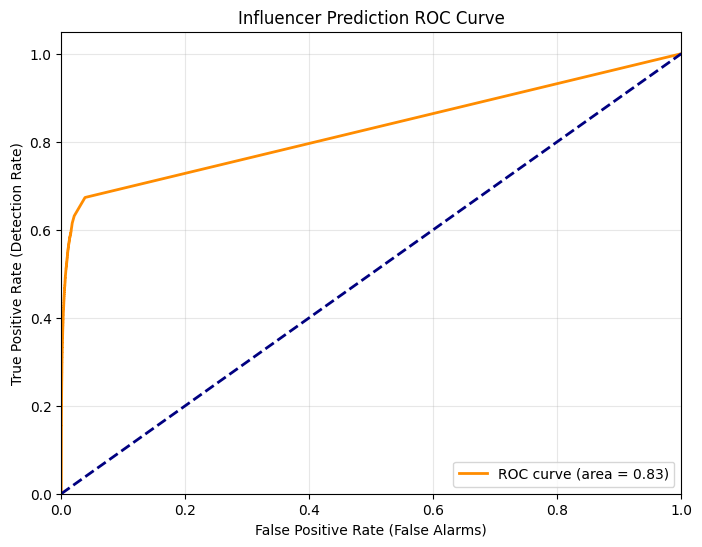

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# 1. Gather all predictions and actual answers from the test set
model.eval()
y_true = []
y_probs = []

with torch.no_grad():
    for g in test:
        g = g.to(device)
        # Get the probability of being in Class 1 (Influencer)
        p = F.softmax(model(g), dim=1)[:, 1].cpu().numpy()
        y_true.extend(g.y.cpu().numpy())
        y_probs.extend(p)

# 2. Calculate the ROC curve data
fpr, tpr, thresholds = roc_curve(y_true, y_probs)
roc_auc = auc(fpr, tpr)

# 3. Plotting the results
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # The "Random Guess" line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (False Alarms)')
plt.ylabel('True Positive Rate (Detection Rate)')
plt.title('Influencer Prediction ROC Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()